## 1. LLM의 환각(Hallucination) 체감하기
### 📝 [요구사항 (과제 TODO)]

* **LLM에게 직접 질문하기**

#### 힌트: llm.invoke([HumanMessage(content=...)]) 형태로 호출

In [ ]:
#[해결 코드 및 구현 근거]
# [요구사항 해결]: 외부 지식(RAG) 주입 없이 LLM 단독으로 답변을 생성하도록 유도합니다.
# [구현 근거]: HumanMessage 객체에 질문만 담아 invoke를 호출함으로써, 
# LLM이 도메인 지식(Yes24 정책) 부재 시 어떻게 환각(거짓말)을 일으키는지 대조군을 생성하는 역할입니다.
response = llm.invoke([HumanMessage(content=question)])

![alt text](image.png)

## 2. 키워드 검색 (Lexical Search) 구현
### 📝 [요구사항 (과제 TODO)]

* **키워드 검색 함수를 완성하세요**

#### 힌트: 문서의 page_content에 keyword가 포함되어 있는지 확인

In [ ]:
# 💻 [해결 코드 및 구현 근거]
def keyword_search(documents, keyword):
    results = []
    for doc in documents:
        # [요구사항 해결]: 문서의 내용(page_content)에 특정 문자열(keyword)이 존재하는지 확인합니다.
        # [구현 근거]: 대소문자 차이로 인한 검색 누락을 막기 위해 lower()로 정규화한 뒤 파이썬의 'in' 연산자를 사용하여 가장 원시적인 형태의 텍스트 매칭 검색기를 구현한 것입니다.
        if keyword.lower() in doc.page_content.lower():
            results.append(doc)
    return results

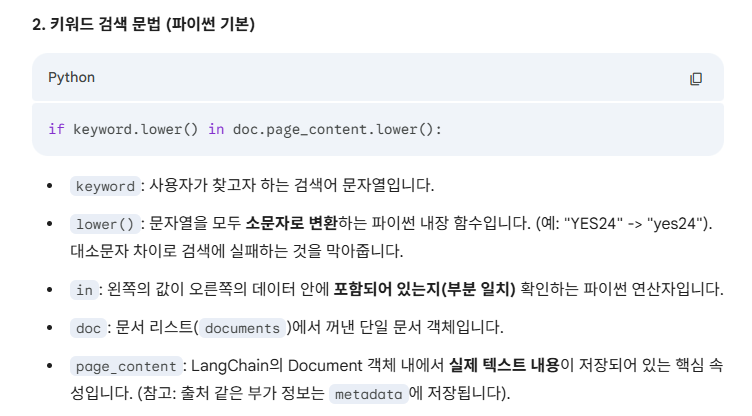

## 3. Vector Store (의미 기반 검색소) 생성
### 📝 [요구사항 (과제 TODO)]

* **Vector Store 생성 (문서 단위 - 페이지별)**

#### 힌트: Chroma.from_documents(documents=..., embedding=..., collection_name=...)

In [ ]:
#[해결 코드 및 구현 근거]
# [요구사항 해결]: 텍스트 데이터를 임베딩 벡터로 변환하여 Chroma DB에 저장합니다.
# [구현 근거]: 단순 텍스트 일치가 아닌 의미적 유사도(Cosine Similarity)로 문서를 찾기 위한 필수 데이터베이스 적재 과정입니다. 문서(all_documents)와 임베딩 모델(embeddings)을 필수 인자로 전달해야 합니다.
vectorstore = Chroma.from_documents(
    documents=all_documents, 
    embedding=embeddings, 
    collection_name="yes24_service_docs"
)

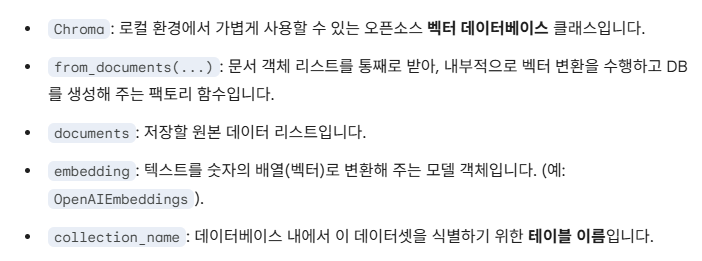

## 4. 최적 청킹(Chunking) 설정 및 분할
### 📝 [요구사항 (과제 TODO)]

* **최적 청킹 설정을 선택하고 전체 문서를 청킹하세요**

#### 권장 설정: chunk_size=300, chunk_overlap=50

In [ ]:
# [요구사항 해결]: 긴 문서를 검색에 용이한 최적의 크기로 자릅니다.
# [구현 근거]: RecursiveCharacterTextSplitter를 사용하여 문장이 중간에 잘리지 않도록(separators) 합니다. chunk_size(300)는 정보의 응집도를, chunk_overlap(50)은 분할 면에서의 문맥 유실 방지 역할을 합니다.
final_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    length_function=len,
    separators=["\n\n", "\n", ".", " ", ""]
)
# [요구사항 해결]: 생성된 분할기(splitter)로 실제 문서를 분할하여 리스트로 반환합니다.
chunked_documents = final_splitter.split_documents(all_documents)

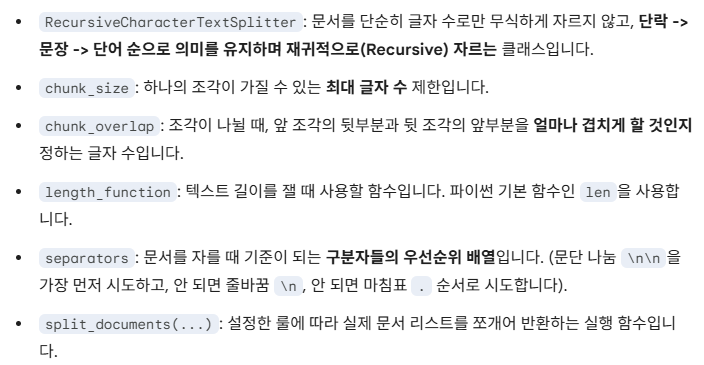

## 5. LangGraph 노드 구현 및 파이프라인 조립
### 📝 [요구사항 (과제 TODO)]

* **retrieve 노드: 질문으로 관련 문서 검색**

#### 힌트: retriever_chunked.invoke(question)을 사용하여 문서를 검색하고 {"context": ...} 형태로 반환

In [ ]:
def retrieve(state: RAGState) -> RAGState:
    # [요구사항 해결]: 사용자 질문을 기반으로 Vector Store에서 가장 유사한 문서를 찾아옵니다.
    # [구현 근거]: retriever를 호출(invoke)하여 검색한 뒤, 다음 생성(generate) 노드가 활용할 수 있도록 문서 내용들을 하나의 텍스트 블록(context)으로 포맷팅하여 상태(State)에 저장합니다.
    docs = retriever_chunked.invoke(state["question"])
    context = "\n\n".join([doc.page_content for doc in docs])
    return {"context": context}

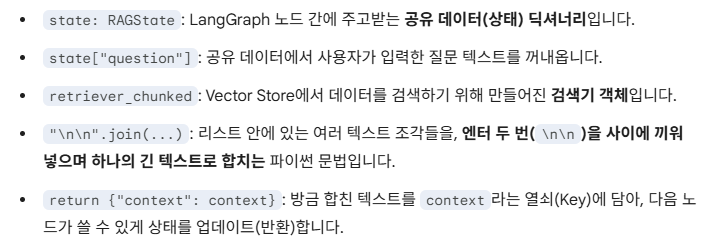

## 📝 [요구사항 (과제 TODO)]

* **generate 노드: 검색된 문서로 답변 생성**

#### 힌트: state에서 question과 context를 가져와서 프롬프트를 생성하고 llm.invoke로 답변 반환

In [ ]:
def generate(state: RAGState) -> RAGState:
    # [요구사항 해결]: 검색된 지식(context)을 프롬프트에 주입하여 LLM의 답변을 생성합니다.
    # [구현 근거]: 시스템 룰(prompt_template)에 상태값들을 채워 넣고(format_messages), 이를 LLM에 전달하여 환각이 억제된 최종 답변(answer)을 도출합니다.
    messages = prompt_template.format_messages(context=state["context"], question=state["question"])
    response = llm.invoke(messages)
    return {"answer": response.content}

## 📝 [요구사항 (과제 TODO)]

* **StateGraph 구성**

#### 노드 추가, 엣지 연결, 그래프 컴파일

In [ ]:
# [요구사항 해결]: 개별 함수들을 하나의 연속적인 워크플로우로 연결합니다.
workflow = StateGraph(RAGState)
workflow.add_node("retrieve", retrieve)  # 검색 컴포넌트 등록
workflow.add_node("generate", generate)  # 생성 컴포넌트 등록

# [구현 근거]: 실행 순서를 명시적으로 고정합니다. '검색'을 먼저 수행하고, 그 결과를 들고 '생성'을 수행하도록 엣지(Edge)를 정의한 후 최종 애플리케이션으로 컴파일합니다.
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)
rag_graph = workflow.compile()

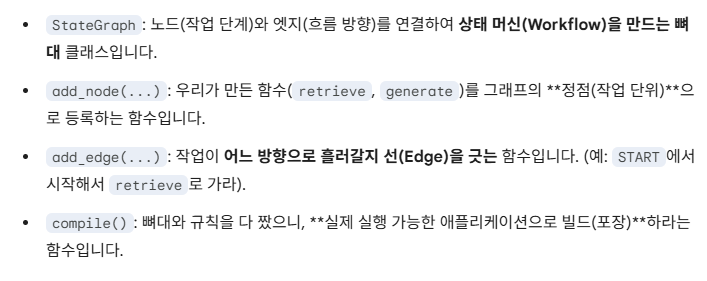

## 6. 청킹(Chunking) 전략 변경 및 비교 (하이퍼파라미터 튜닝)
### 📝 [요구사항 (과제 TODO)]

* **chunk_size 값 변경하여 비교**

**설정 A: 작은 chunk_size (200)**, 
**설정 B: 큰 chunk_size (500)**

#### 힌트: create_vectorstore_with_chunking(all_documents, chunk_size=200, chunk_overlap=20, collection_name="...")

In [ ]:
# [요구사항 해결]: 주어진 힌트의 파라미터를 그대로 적용하여 200자 단위의 잘게 쪼갠 Vector Store를 생성합니다.
# [구현 근거]: chunk_size가 작을 때 특정 수치나 단답형 키워드는 잘 찾지만 문맥이 어떻게 잘려나가는지 확인하기 위한 '비교군 A'를 만드는 과정입니다.
vectorstore_small, chunks_small = create_vectorstore_with_chunking(
    all_documents,
    chunk_size=200,
    chunk_overlap=20,
    collection_name="yes24_small"
)

# [요구사항 해결]: chunk_size를 500으로 늘려 더 큰 덩어리의 Vector Store를 생성합니다.
# [구현 근거]: chunk_size가 클 때 예외 조항이나 문맥은 잘 유지되지만, 불필요한 노이즈가 얼마나 섞이는지 확인하기 위한 '비교군 B'를 만드는 과정입니다.
vectorstore_large, chunks_large = create_vectorstore_with_chunking(
    all_documents,
    chunk_size=500,
    chunk_overlap=50,
    collection_name="yes24_large"
)

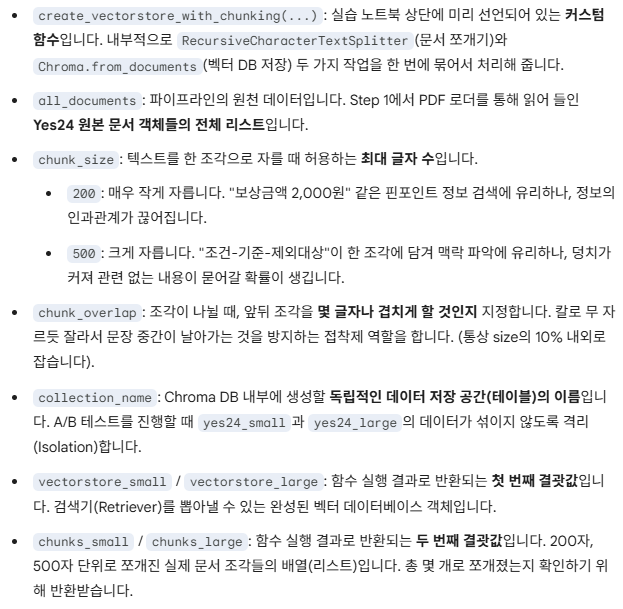